# Combined PD + 3C + 4C Report (Standalone)

This notebook is a **separate integrated report** that combines three biologically distinct assay layers:

- **PD**: DSB outcome profiling, including repair state and trans-repair frequency
- **3C**: construct-focused recombination/contact readout within the engineered system
- **4C**: genome-wide interaction profile of the **DSB2 viewport** against the rest of the genome
- A multi-assay hotspot localization layer that asks where these signals align after break induction

For 4C, this report is downstream of the FourC Python workflow: raw aligned 4C input is defined in `SAM_SAMPLES` in `FourC_OneShot_Python_Report.ipynb`, and processed outputs are written under `Outputs/4C_python`.

## Outputs
1. PD+3C integrated contact maps
2. PD vs 3C concordance
3. Differential integrated map (Cut DSB - Uncut DSB)
4. 4C viewpoint profile + 4C-style MA change plot
5. Multi-assay region localization ranking (intact/induced DSB, SSA vs not-SSA)
6. Chromosome mobility and enrichment maps linking 3C construct recombination, 4C genome interactions, and PD repair/trans-repair behavior

In [30]:
suppressPackageStartupMessages({
  library(tidyverse)
})

state_uncut <- 'Uncut DSB'
state_cut <- 'Cut DSB'
valid_time_points <- c(0, 120, 180)
two_state_map <- c('0' = state_uncut, '120' = state_cut, '180' = state_cut)

normalize_time_point <- function(tp) {
  suppressWarnings(readr::parse_number(as.character(tp)))
}

filter_two_timepoint_rows <- function(df, tp_col = 'time_point') {
  df %>%
    mutate(..tp_num = normalize_time_point(.data[[tp_col]])) %>%
    filter(..tp_num %in% valid_time_points) %>%
    mutate(time_point = ..tp_num) %>%
    select(-..tp_num)
}

assign_state <- function(tp, map_vec, uncut_label = state_uncut, cut_label = state_cut) {
  tp_chr <- as.character(tp)
  mapped <- unname(map_vec[tp_chr])
  tp_num <- suppressWarnings(as.numeric(tp_chr))
  min_tp <- suppressWarnings(min(tp_num, na.rm = TRUE))
  fallback <- ifelse(!is.na(tp_num) & tp_num == min_tp, uncut_label, cut_label)
  ifelse(is.na(mapped), fallback, mapped)
}

sparse_axis_labels <- function(x, step = 4) {
  labs <- sub('^.*__', '', x)
  idx <- seq_along(labs)
  labs[!(idx %% step == 1)] <- ''
  labs
}

In [31]:
# ---- Load PD ---- (patched)
pd_folder <- Sys.getenv('WILSONTEW_PD_FOLDER', unset = file.path(getwd(), 'PD_Data'))
pd_folder <- normalizePath(pd_folder, winslash = '/', mustWork = FALSE)
pd_files <- list.files(pd_folder, pattern = '(_summary|_collapsed_summary)\\.csv$', full.names = TRUE)
if (length(pd_files) == 0) stop('No PD summary files found.')

read_pd <- function(f) {
  x <- readr::read_csv(f, show_col_types = FALSE)
  req <- c('batch','time_point','DSB','allele','combo','count')
  missing <- setdiff(req, names(x))
  if (length(missing) > 0) stop(paste('Missing PD columns in', basename(f), ':', paste(missing, collapse = ', ')))
  x %>%
    mutate(
      batch = as.character(batch),
      time_point = as.character(time_point),
      DSB = as.character(DSB),
      allele = as.character(allele),
      combo = as.character(combo),
      count = as.numeric(count)
    )
}

dat_raw <- purrr::map_dfr(pd_files, read_pd)
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
dat4 <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  filter_two_timepoint_rows('time_point')
if (nrow(dat4) == 0) stop('No rows for 4-combo PD set.')

pd_state_map <- two_state_map
threec_state_map <- two_state_map

pd_sig <- dat4 %>%
  mutate(state = assign_state(time_point, pd_state_map)) %>%
  group_by(DSB, state, combo, allele) %>%
  summarise(PD_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state, combo) %>%
  mutate(
    PD_Total = sum(PD_Counts, na.rm = TRUE),
    PD_Freq = if_else(PD_Total > 0, PD_Counts / PD_Total, 0)
  ) %>%
  ungroup()

# ---- Load 3C ----
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)
threec_files <- c(
  list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE),
  list.files(threec_folder, pattern = '_collapsed_summary\\.csv$', full.names = TRUE)
) %>% unique()
if (length(threec_files) == 0) stop('No 3C summary files found. Set WILSONTEW_3C_FOLDER.')

read_threec <- function(f) {
  x <- readr::read_csv(f, show_col_types = FALSE, col_types = readr::cols(.default = readr::col_character()))
  req <- c('DSB','time_point','combo','allele','count')
  if (!all(req %in% names(x))) return(NULL)
  x %>%
    transmute(
      DSB = as.character(DSB),
      time_point = readr::parse_number(as.character(time_point)),
      combo = as.character(combo),
      allele = as.character(allele),
      count = readr::parse_double(as.character(count))
    )
}

threec_raw <- purrr::map(threec_files, read_threec) %>% purrr::compact() %>% dplyr::bind_rows()
threec_raw <- filter_two_timepoint_rows(threec_raw, 'time_point')
if (nrow(threec_raw) == 0) stop('3C files found but required columns were missing.')

threec_sig <- threec_raw %>%
  mutate(state = assign_state(time_point, threec_state_map)) %>%
  filter(combo %in% combos_4) %>%
  group_by(DSB, state, combo, allele) %>%
  summarise(ThreeC_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state, combo) %>%
  mutate(
    ThreeC_Total = sum(ThreeC_Counts, na.rm = TRUE),
    ThreeC_Freq = if_else(ThreeC_Total > 0, ThreeC_Counts / ThreeC_Total, 0)
  ) %>%
  ungroup()

# ---- Build integrated score ----
fusion_df <- full_join(
  pd_sig %>% select(DSB, state, combo, allele, PD_Freq),
  threec_sig %>% select(DSB, state, combo, allele, ThreeC_Freq),
  by = c('DSB','state','combo','allele')
) %>%
  mutate(
    PD_Freq = replace_na(PD_Freq, 0),
    ThreeC_Freq = replace_na(ThreeC_Freq, 0),
    Integrated_Raw = if_else(PD_Freq + ThreeC_Freq > 0, 2 * PD_Freq * ThreeC_Freq / (PD_Freq + ThreeC_Freq), 0)
  ) %>%
  group_by(DSB, state) %>%
  mutate(
    Integrated_Max = max(Integrated_Raw, na.rm = TRUE),
    Integrated_Score = if_else(Integrated_Max > 0, Integrated_Raw / Integrated_Max, 0)
  ) %>%
  ungroup()

message('PD files: ', length(pd_files), ' | 3C files: ', length(threec_files))

PD files: 4 | 3C files: 8



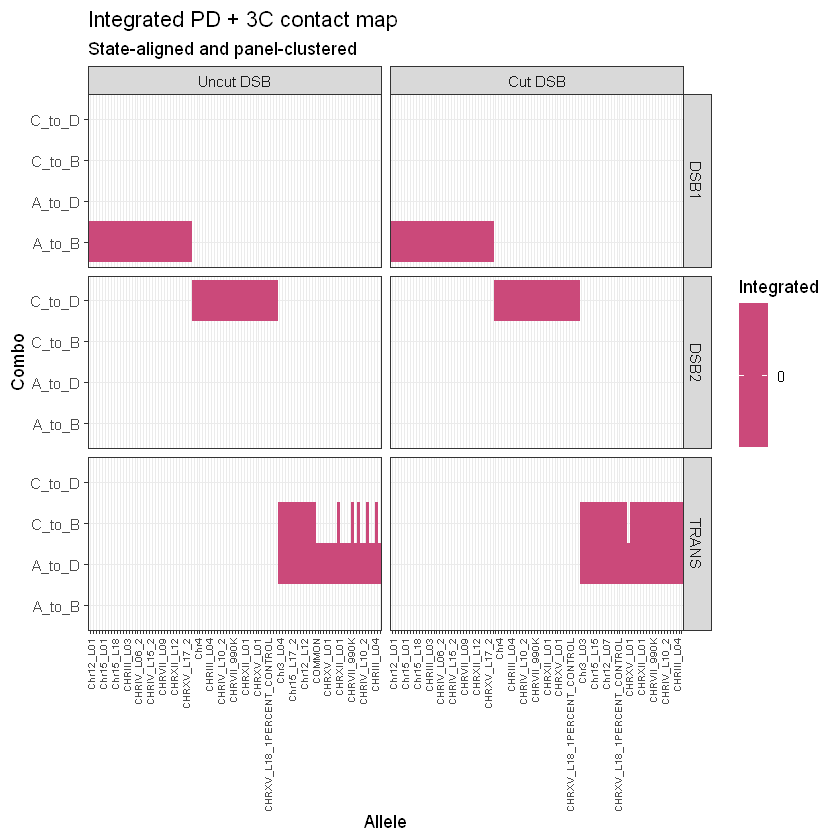

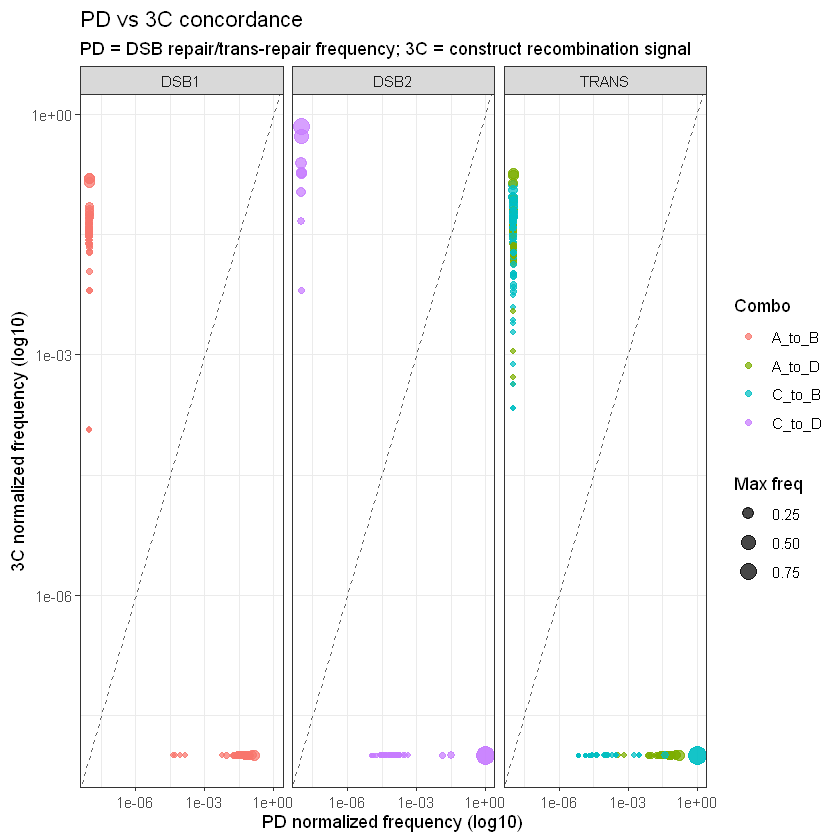

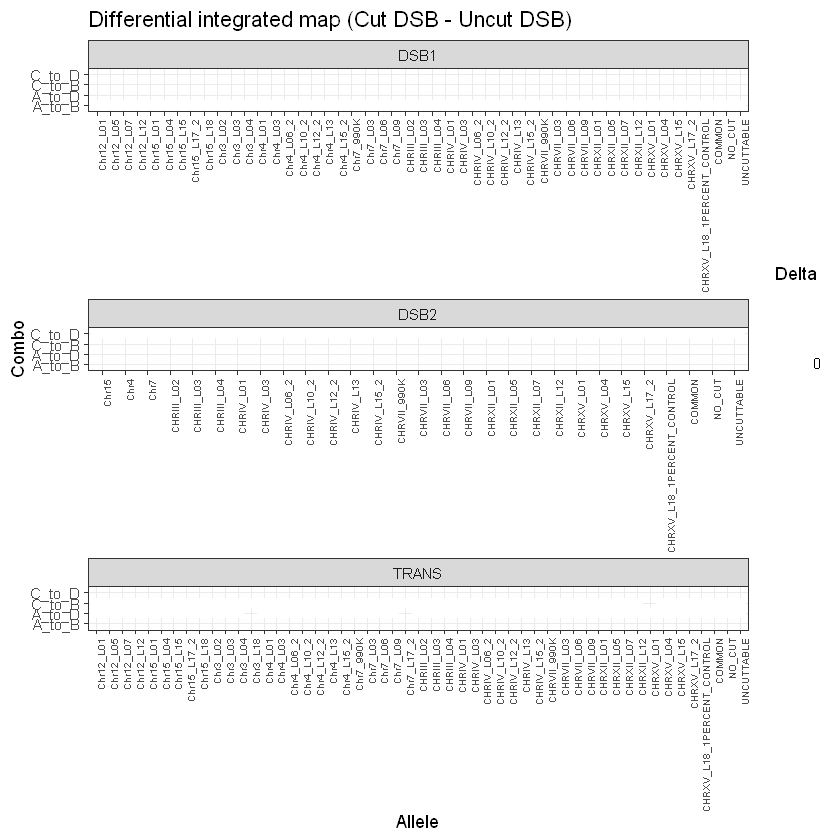

In [32]:
# ---- Integrated plots ----
top_n <- 35
top_alleles_panel <- fusion_df %>%
  group_by(DSB, state, allele) %>%
  summarise(Total_Integrated = sum(Integrated_Score, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state) %>%
  slice_max(order_by = Total_Integrated, n = top_n, with_ties = FALSE) %>%
  ungroup()

fusion_plot <- fusion_df %>%
  inner_join(top_alleles_panel %>% select(DSB, state, allele), by = c('DSB','state','allele'))

panel_orders <- fusion_plot %>%
  group_by(DSB, state) %>%
  group_modify(~ {
    wide <- .x %>%
      select(allele, combo, Integrated_Score) %>%
      distinct() %>%
      pivot_wider(names_from = combo, values_from = Integrated_Score, values_fill = 0)
    allele_names <- wide$allele
    mat <- wide %>% select(-allele) %>% as.matrix()
    ord <- if (length(allele_names) >= 3 && ncol(mat) >= 2) allele_names[hclust(dist(mat), method = 'ward.D2')$order] else sort(allele_names)
    tibble(allele = ord, allele_ord = seq_along(ord))
  }) %>%
  ungroup()

fusion_plot <- fusion_plot %>%
  left_join(panel_orders, by = c('DSB','state','allele')) %>%
  mutate(
    state = factor(state, levels = c(state_uncut, state_cut)),
    panel_key = paste0(DSB, '__', as.character(state)),
    allele_panel = paste0(panel_key, '__', sprintf('%03d', allele_ord), '__', allele)
  )

allele_panel_levels <- fusion_plot %>%
  distinct(DSB, state, allele_ord, allele_panel) %>%
  arrange(DSB, state, allele_ord) %>%
  pull(allele_panel)

fusion_plot <- fusion_plot %>% mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

p_integrated <- ggplot(fusion_plot, aes(x = allele_panel, y = combo, fill = sqrt(Integrated_Score))) +
  geom_tile() +
  facet_grid(DSB ~ state, scales = 'free_x', space = 'free_x') +
  scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
  scale_fill_viridis_c(option = 'C', na.value = 'grey90') +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6)) +
  labs(title = 'Integrated PD + 3C contact map', subtitle = 'State-aligned and panel-clustered', x = 'Allele', y = 'Combo', fill = 'Integrated')
print(p_integrated)

p_concordance <- ggplot(
  fusion_df %>% filter(PD_Freq > 0 | ThreeC_Freq > 0),
  aes(x = PD_Freq + 1e-8, y = ThreeC_Freq + 1e-8, color = combo, size = pmax(PD_Freq, ThreeC_Freq))
) +
  geom_point(alpha = 0.72) +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed', color = 'grey40') +
  scale_x_log10() +
  scale_y_log10() +
  scale_size_continuous(range = c(1.2, 5), name = 'Max freq') +
  facet_wrap(~ DSB) +
  theme_bw(base_size = 11) +
  labs(title = 'PD vs 3C concordance', subtitle = 'PD = DSB repair/trans-repair frequency; 3C = construct recombination signal', x = 'PD normalized frequency (log10)', y = '3C normalized frequency (log10)', color = 'Combo')
print(p_concordance)

if (all(c(state_uncut, state_cut) %in% unique(fusion_df$state))) {
  diff_df <- fusion_df %>%
    select(DSB, state, combo, allele, Integrated_Score) %>%
    pivot_wider(names_from = state, values_from = Integrated_Score, values_fill = 0) %>%
    mutate(Delta = .data[[state_cut]] - .data[[state_uncut]])

  p_diff <- ggplot(diff_df, aes(x = allele, y = combo, fill = Delta)) +
    geom_tile() +
    facet_wrap(~ DSB, ncol = 1, scales = 'free_x') +
    scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0) +
    theme_bw(base_size = 11) +
    theme(axis.text.x = element_text(angle = 90, size = 6, hjust = 1)) +
    labs(title = 'Differential integrated map (Cut DSB - Uncut DSB)', x = 'Allele', y = 'Combo', fill = 'Delta')
  print(p_diff)
}

## 4C block

This section looks for 4C-derived CSV summaries in `WILSONTEW_4C_FOLDER` (default: `./Outputs/4C_python`).

In this project, canonical 4C input is configured in `SAM_SAMPLES` inside `FourC_OneShot_Python_Report.ipynb`, and that workflow writes processed outputs to `Outputs/4C_python`.

This report prefers real 4C summary-style files when available and otherwise reads `binned_contact_counts.csv` from `Outputs/4C_python`.

Biologically, the real 4C layer is the assay that measures how the **DSB2 viewport interacts with the whole genome**.

Using real 4C binned contacts from: C:/Users/dunnmk/wilsontew-data-analysis/Outputs/4C_python/binned_contact_counts.csv

4C contains a single state/time context here; Cut-vs-Uncut 4C comparison plots will be skipped.



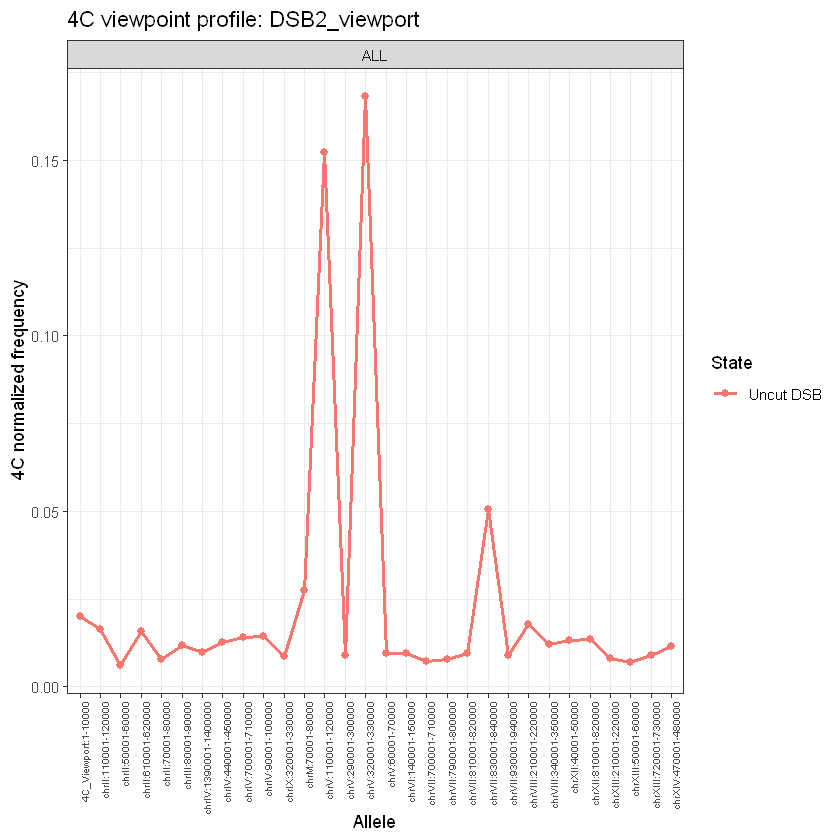

In [39]:
# ---- 4C data (real outputs only; no synthetic proxy comparisons) ----
fourc_folder <- Sys.getenv('WILSONTEW_4C_FOLDER', unset = file.path(getwd(), 'Outputs', '4C_python'))
fourc_folder <- normalizePath(fourc_folder, winslash = '/', mustWork = FALSE)
fourc_summary_files <- list.files(fourc_folder, pattern = '(_summary|_collapsed_summary)\\.csv$', full.names = TRUE)
fourc_binned_file <- file.path(fourc_folder, 'binned_contact_counts.csv')

read_fourc_summary <- function(f) {
  x <- readr::read_csv(f, show_col_types = FALSE, col_types = readr::cols(.default = readr::col_character()))
  if (!('allele' %in% names(x)) || !('count' %in% names(x))) return(NULL)
  x %>%
    mutate(
      DSB = if ('DSB' %in% names(x)) as.character(DSB) else 'ALL',
      time_point = if ('time_point' %in% names(x)) as.character(time_point) else '0',
      viewpoint = if ('viewpoint' %in% names(x)) as.character(viewpoint) else if ('combo' %in% names(x)) as.character(combo) else 'DSB2_viewport',
      allele = as.character(allele),
      count = readr::parse_double(as.character(count)),
      Freq4C = NA_real_
    ) %>%
    select(DSB, time_point, viewpoint, allele, count, Freq4C)
}

read_fourc_binned <- function(f) {
  x <- readr::read_csv(f, show_col_types = FALSE, col_types = readr::cols(.default = readr::col_character()))
  req <- c('sample', 'time_point', 'chrom', 'bin_id', 'count')
  if (!all(req %in% names(x))) return(NULL)
  x %>%
    transmute(
      DSB = if ('DSB' %in% names(x)) as.character(.data[['DSB']]) else 'ALL',
      time_point = as.character(.data[['time_point']]),
      viewpoint = 'DSB2_viewport',
      allele = as.character(.data[['bin_id']]),
      count = readr::parse_double(as.character(.data[['count']])),
      Freq4C = if ('freq' %in% names(x)) readr::parse_double(as.character(.data[['freq']])) else NA_real_
    )
}

fourc_mode <- 'none'
if (length(fourc_summary_files) > 0) {
  fourc_raw <- purrr::map(fourc_summary_files, read_fourc_summary) %>% purrr::compact() %>% bind_rows()
  if (nrow(fourc_raw) > 0) {
    fourc_mode <- 'summary'
  } else if (file.exists(fourc_binned_file)) {
    fourc_raw <- read_fourc_binned(fourc_binned_file)
    fourc_mode <- 'binned'
  }
} else if (file.exists(fourc_binned_file)) {
  fourc_raw <- read_fourc_binned(fourc_binned_file)
  fourc_mode <- 'binned'
} else {
  fourc_raw <- tibble()
}

has_fourc_state_pair <- FALSE
if (nrow(fourc_raw) > 0) {
  fourc_raw <- filter_two_timepoint_rows(fourc_raw, 'time_point')
  fourc_sig <- fourc_raw %>%
    mutate(state = assign_state(time_point, two_state_map)) %>%
    group_by(DSB, state, viewpoint, allele) %>%
    summarise(
      count = sum(count, na.rm = TRUE),
      Freq4C_input = suppressWarnings(mean(Freq4C, na.rm = TRUE)),
      .groups = 'drop'
    ) %>%
    group_by(DSB, state, viewpoint) %>%
    mutate(
      FourC_Total = sum(count, na.rm = TRUE),
      Freq4C_count = if_else(FourC_Total > 0, count / FourC_Total, 0),
      Freq4C = if_else(is.finite(Freq4C_input), Freq4C_input, Freq4C_count)
    ) %>%
    ungroup() %>%
    select(DSB, state, viewpoint, allele, count, Freq4C)

  has_fourc_state_pair <- all(c(state_uncut, state_cut) %in% unique(fourc_sig$state))

  if (fourc_mode == 'binned') {
    message('Using real 4C binned contacts from: ', fourc_binned_file)
  } else {
    message('Using real 4C summary files from: ', fourc_folder)
  }

  if (!has_fourc_state_pair) {
    message('4C contains a single state/time context here; Cut-vs-Uncut 4C comparison plots will be skipped.')
  }
} else {
  fourc_sig <- tibble(DSB = character(), state = character(), viewpoint = character(), allele = character(), count = numeric(), Freq4C = numeric())
  message('No compatible real 4C files found in ', fourc_folder, '; skipping 4C comparison plots (no proxy generated).')
}

# 4C viewpoint profile (real data only)
if (nrow(fourc_sig) > 0) {
  focus_view <- fourc_sig %>% count(viewpoint, sort = TRUE) %>% slice(1) %>% pull(viewpoint)
  profile_df <- fourc_sig %>%
    filter(viewpoint == focus_view) %>%
    group_by(DSB, allele) %>%
    mutate(mean_freq = mean(Freq4C, na.rm = TRUE)) %>%
    ungroup() %>%
    group_by(DSB) %>%
    slice_max(order_by = mean_freq, n = 30, with_ties = FALSE) %>%
    ungroup()

  p_4c_profile <- ggplot(profile_df, aes(x = allele, y = Freq4C, color = state, group = state)) +
    geom_line(linewidth = 0.9) +
    geom_point(size = 1.8) +
    facet_wrap(~ DSB, scales = 'free_y') +
    theme_bw(base_size = 11) +
    theme(axis.text.x = element_text(angle = 90, size = 6, hjust = 1)) +
    labs(title = paste0('4C viewpoint profile: ', focus_view), x = 'Allele', y = '4C normalized frequency', color = 'State')
  print(p_4c_profile)
}

# 4C MA state-change plot only when both states exist
if (nrow(fourc_sig) > 0 && has_fourc_state_pair) {
  ma_df <- fourc_sig %>%
    select(DSB, viewpoint, allele, state, Freq4C) %>%
    pivot_wider(names_from = state, values_from = Freq4C, values_fill = 0) %>%
    mutate(
      A = 0.5 * log10((.data[[state_cut]] + 1e-8) * (.data[[state_uncut]] + 1e-8)),
      M = log2((.data[[state_cut]] + 1e-8) / (.data[[state_uncut]] + 1e-8))
    )

  label_ma <- ma_df %>%
    group_by(DSB, viewpoint) %>%
    slice_max(order_by = abs(M), n = 8, with_ties = FALSE) %>%
    ungroup()

  p_4c_ma <- ggplot(ma_df, aes(x = A, y = M, color = viewpoint)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey45') +
    geom_point(alpha = 0.75, size = 1.8) +
    geom_text(data = label_ma, aes(label = allele), size = 2.6, check_overlap = TRUE, show.legend = FALSE, vjust = -0.3) +
    facet_wrap(~ DSB, scales = 'free') +
    theme_bw(base_size = 11) +
    labs(title = '4C MA plot (Cut vs Uncut)', subtitle = 'Shown only when both states are present in real 4C data', x = 'A', y = 'M', color = 'Viewpoint')
  print(p_4c_ma)
}

## Multi-assay localization of candidate repair regions

This block integrates region-level signal from three assays with different meanings:

- **PD** measures the DSB, its repair outcome, and trans-repair frequency
- **3C** measures how the engineered construct recombines within the construct-focused system
- **4C** measures how the **DSB2 viewport** interacts with the rest of the genome

It additionally stratifies by **SSA vs not-SSA/intact** where repeat metadata is available,
so hotspot localization is interpreted in the right biological frame for each assay.

When an assay lacks paired Cut/Uncut states, the notebook now keeps that channel as unpaired context instead of fabricating contrast values.

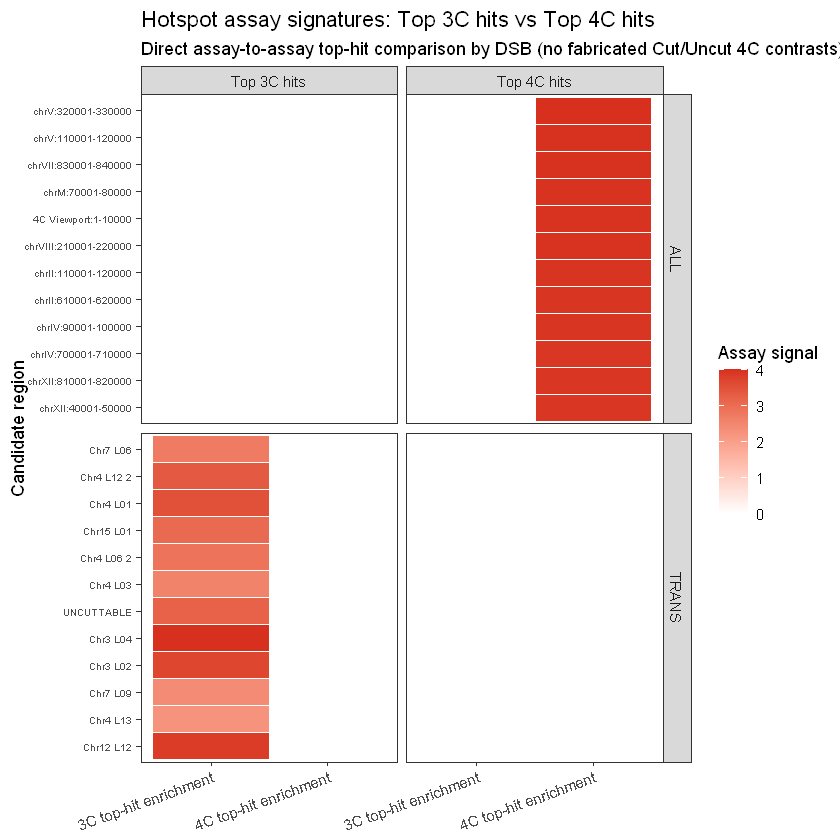

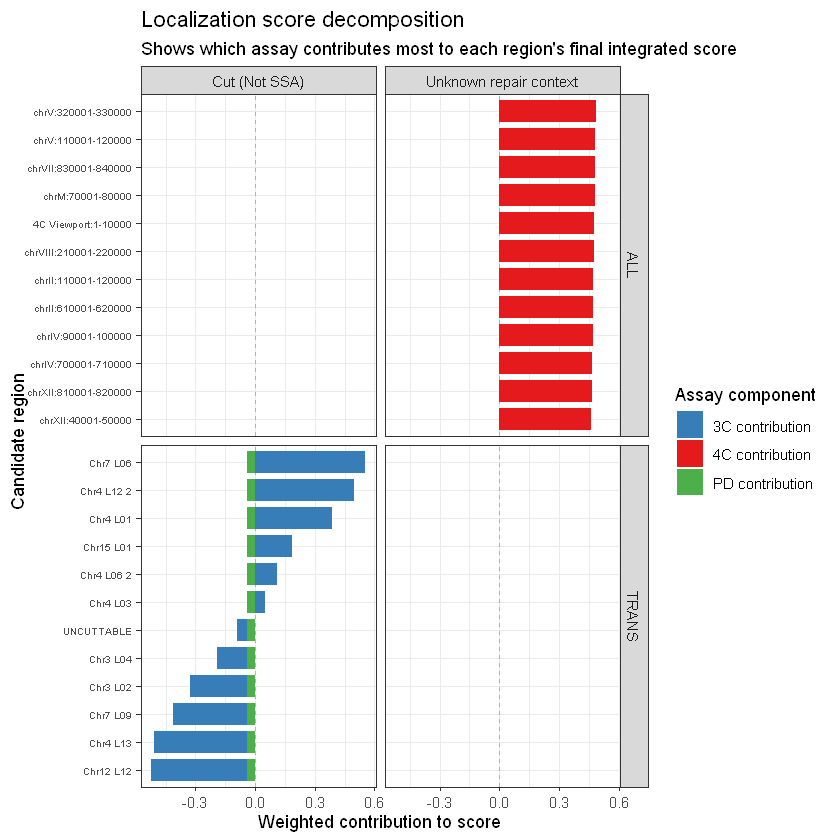

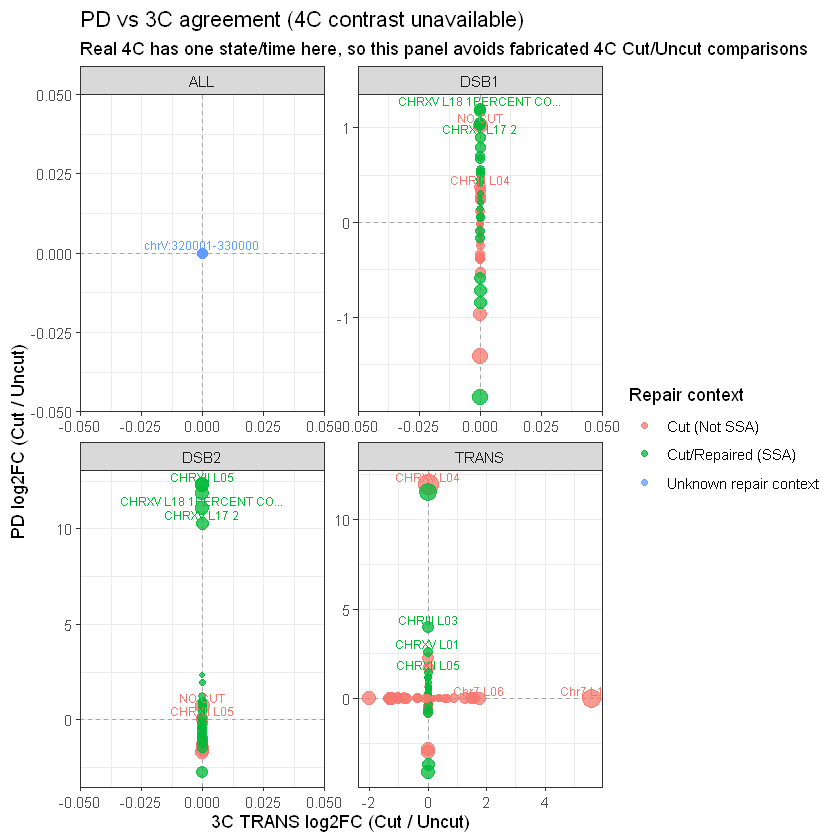

Built localization ranking: 634 region rows across assay signals.



DSB,hit_source,rank,location,assay,signal_value,Localization_Score,agreement
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>
ALL,Top 4C hits,1,chrV:320001-330000,3C top-hit enrichment,0.000000,0.4848709,4C-biased hit
ALL,Top 4C hits,1,chrV:320001-330000,4C top-hit enrichment,4.000000,0.4848709,4C-biased hit
ALL,Top 4C hits,2,chrV:110001-120000,3C top-hit enrichment,0.000000,0.4828759,4C-biased hit
ALL,Top 4C hits,2,chrV:110001-120000,4C top-hit enrichment,3.991247,0.4828759,4C-biased hit
ALL,Top 4C hits,3,chrVII:830001-840000,3C top-hit enrichment,0.000000,0.4808808,4C-biased hit
ALL,Top 4C hits,3,chrVII:830001-840000,4C top-hit enrichment,3.982495,0.4808808,4C-biased hit
ALL,Top 4C hits,4,chrM:70001-80000,3C top-hit enrichment,0.000000,0.4788857,4C-biased hit
ALL,Top 4C hits,4,chrM:70001-80000,4C top-hit enrichment,3.973742,0.4788857,4C-biased hit
ALL,Top 4C hits,5,4C_Viewport:1-10000,3C top-hit enrichment,0.000000,0.4768907,4C-biased hit


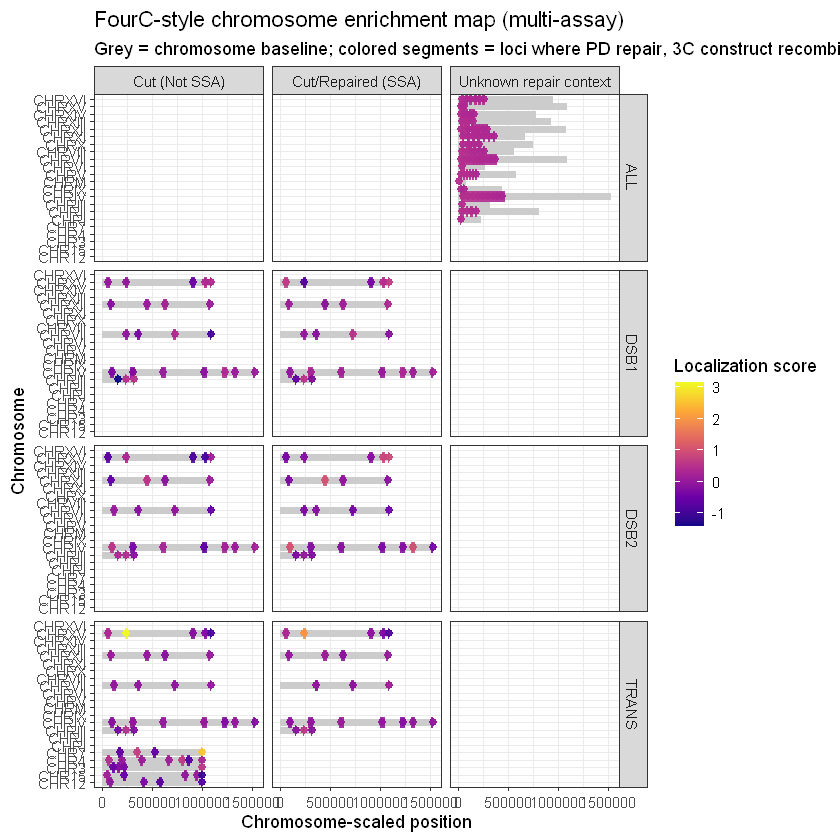

In [45]:
# ---- Multi-assay hotspot localization (PD + 3C TRANS + 4C) ----
eps_loc <- 1e-8

classify_repair_mode <- function(x) {
  x <- tolower(as.character(x))
  case_when(
    str_detect(x, 'ssa') ~ 'Cut/Repaired (SSA)',
    str_detect(x, 'intact|not\\s*ssa|no\\s*ssa|non\\s*ssa|all') ~ 'Cut (Not SSA)',
    is.na(x) | x == '' ~ 'Unknown repair context',
    TRUE ~ 'Other repair context'
  )
}

extract_chr <- function(allele_chr) {
  allele_chr <- as.character(allele_chr)
  out <- stringr::str_extract(allele_chr, '(?i)chr[0-9ivxym]+')
  out <- ifelse(is.na(out), stringr::str_extract(allele_chr, '(?i)^(?:[ivx]{1,4}|[0-9]{1,2})$'), out)
  out <- ifelse(is.na(out), NA_character_, toupper(out))
  out
}

zsafe <- function(x) {
  s <- stats::sd(x, na.rm = TRUE)
  m <- mean(x, na.rm = TRUE)
  if (!is.finite(s) || s == 0) return(rep(0, length(x)))
  (x - m) / s
}

# PD localization by state and repair context
pd_local <- dat4 %>%
  mutate(
    state = assign_state(time_point, pd_state_map),
    repair_mode = classify_repair_mode(if ('repeat' %in% names(.)) .data[['repeat']] else NA_character_),
    location = as.character(allele)
  ) %>%
  group_by(DSB, repair_mode, state, location) %>%
  summarise(PD_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, repair_mode, state) %>%
  mutate(
    PD_Total = sum(PD_Counts, na.rm = TRUE),
    PD_Freq = if_else(PD_Total > 0, PD_Counts / PD_Total, 0)
  ) %>%
  ungroup()

pd_local_wide <- pd_local %>%
  select(DSB, repair_mode, location, state, PD_Freq) %>%
  pivot_wider(names_from = state, values_from = PD_Freq, values_fill = 0) %>%
  mutate(
    PD_log2FC_Cut_vs_Uncut = log2((.data[[state_cut]] + eps_loc) / (.data[[state_uncut]] + eps_loc)),
    PD_delta_Cut_minus_Uncut = .data[[state_cut]] - .data[[state_uncut]]
  )

# 3C localization by TRANS-only fold change and repair context (optional repeat column)
read_threec_local <- function(f) {
  x <- readr::read_csv(f, show_col_types = FALSE, col_types = readr::cols(.default = readr::col_character()))
  req <- c('DSB','time_point','combo','allele','count')
  if (!all(req %in% names(x))) return(NULL)
  x %>%
    transmute(
      DSB = as.character(.data[['DSB']]),
      time_point = readr::parse_number(as.character(.data[['time_point']])),
      combo = as.character(.data[['combo']]),
      allele = as.character(.data[['allele']]),
      count = readr::parse_double(as.character(.data[['count']])),
      repeat_tag = if ('repeat' %in% names(.)) as.character(.data[['repeat']]) else 'ALL'
    )
}

threec_local_raw <- purrr::map(threec_files, read_threec_local) %>% purrr::compact() %>% bind_rows()
threec_local_raw <- filter_two_timepoint_rows(threec_local_raw, 'time_point')

if (nrow(threec_local_raw) > 0) {
  threec_local <- threec_local_raw %>%
    mutate(
      state = assign_state(time_point, two_state_map),
      repair_mode = classify_repair_mode(repeat_tag),
      location = as.character(allele)
    ) %>%
    filter(combo %in% c('A_to_D', 'C_to_B')) %>%
    group_by(DSB, repair_mode, state, location) %>%
    summarise(ThreeC_TRANS_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(DSB, repair_mode, state) %>%
    mutate(
      ThreeC_TRANS_Total = sum(ThreeC_TRANS_Counts, na.rm = TRUE),
      ThreeC_TRANS_Freq = if_else(ThreeC_TRANS_Total > 0, ThreeC_TRANS_Counts / ThreeC_TRANS_Total, 0)
    ) %>%
    ungroup()

  threec_local_wide <- threec_local %>%
    select(DSB, repair_mode, location, state, ThreeC_TRANS_Freq) %>%
    pivot_wider(names_from = state, values_from = ThreeC_TRANS_Freq, values_fill = 0) %>%
    mutate(
      ThreeC_TRANS_log2FC_Cut_vs_Uncut = log2((.data[[state_cut]] + eps_loc) / (.data[[state_uncut]] + eps_loc)),
      ThreeC_TRANS_delta_Cut_minus_Uncut = .data[[state_cut]] - .data[[state_uncut]]
    )
} else {
  threec_local <- tibble(
    DSB = character(), repair_mode = character(), state = character(), location = character(),
    ThreeC_TRANS_Counts = numeric(), ThreeC_TRANS_Total = numeric(), ThreeC_TRANS_Freq = numeric()
  )
  threec_local_wide <- tibble(
    DSB = character(), repair_mode = character(), location = character(),
    ThreeC_TRANS_log2FC_Cut_vs_Uncut = numeric(),
    ThreeC_TRANS_delta_Cut_minus_Uncut = numeric()
  )
}

threec_hit_features <- threec_local %>%
  group_by(DSB, repair_mode, location) %>%
  summarise(ThreeC_TRANS_Hit = max(ThreeC_TRANS_Freq, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, repair_mode) %>%
  mutate(ThreeC_TRANS_HitScore = if (dplyr::n() > 1) dplyr::percent_rank(ThreeC_TRANS_Hit) else rep(1, dplyr::n())) %>%
  ungroup()

# 4C location signal (Cut/Uncut contrast only when both states are truly present)
fourc_local <- fourc_sig %>%
  mutate(location = as.character(allele)) %>%
  group_by(DSB, state, location) %>%
  summarise(Freq4C = mean(Freq4C, na.rm = TRUE), .groups = 'drop')

fourc_hit_features <- fourc_local %>%
  group_by(DSB, location) %>%
  summarise(Freq4C_Hit = max(Freq4C, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB) %>%
  mutate(Freq4C_HitScore = if (dplyr::n() > 1) dplyr::percent_rank(Freq4C_Hit) else rep(1, dplyr::n())) %>%
  ungroup()

if (nrow(fourc_local) > 0 && exists('has_fourc_state_pair') && has_fourc_state_pair) {
  fourc_local_wide <- fourc_local %>%
    select(DSB, location, state, Freq4C) %>%
    pivot_wider(names_from = state, values_from = Freq4C, values_fill = 0) %>%
    mutate(
      Freq4C_log2FC_Cut_vs_Uncut = log2((.data[[state_cut]] + eps_loc) / (.data[[state_uncut]] + eps_loc)),
      Freq4C_delta_Cut_minus_Uncut = .data[[state_cut]] - .data[[state_uncut]]
    )
} else if (nrow(fourc_local) > 0) {
  fourc_local_wide <- fourc_local %>%
    group_by(DSB, location) %>%
    summarise(Freq4C_mean = mean(Freq4C, na.rm = TRUE), .groups = 'drop') %>%
    mutate(
      Freq4C_log2FC_Cut_vs_Uncut = NA_real_,
      Freq4C_delta_Cut_minus_Uncut = NA_real_
    )
} else {
  fourc_local_wide <- tibble(
    DSB = character(),
    location = character(),
    Freq4C_log2FC_Cut_vs_Uncut = numeric(),
    Freq4C_delta_Cut_minus_Uncut = numeric()
  )
}

# Join all assays; default missing repair-mode strata to Cut (Not SSA)
localization_ranked <- full_join(
  pd_local_wide,
  threec_local_wide %>% select(DSB, repair_mode, location, ThreeC_TRANS_log2FC_Cut_vs_Uncut, ThreeC_TRANS_delta_Cut_minus_Uncut),
  by = c('DSB','repair_mode','location')
) %>%
  full_join(
    threec_hit_features %>% select(DSB, repair_mode, location, ThreeC_TRANS_HitScore),
    by = c('DSB','repair_mode','location')
  ) %>%
  mutate(repair_mode = replace_na(repair_mode, 'Cut (Not SSA)')) %>%
  full_join(
    fourc_local_wide %>% select(DSB, location, Freq4C_log2FC_Cut_vs_Uncut, Freq4C_delta_Cut_minus_Uncut),
    by = c('DSB','location')
  ) %>%
  full_join(
    fourc_hit_features %>% select(DSB, location, Freq4C_HitScore),
    by = c('DSB','location')
  ) %>%
  mutate(
    PD_log2FC_Cut_vs_Uncut = replace_na(PD_log2FC_Cut_vs_Uncut, 0),
    ThreeC_TRANS_log2FC_Cut_vs_Uncut = replace_na(ThreeC_TRANS_log2FC_Cut_vs_Uncut, 0),
    ThreeC_TRANS_HitScore = replace_na(ThreeC_TRANS_HitScore, 0),
    PD_delta_Cut_minus_Uncut = replace_na(PD_delta_Cut_minus_Uncut, 0),
    ThreeC_TRANS_delta_Cut_minus_Uncut = replace_na(ThreeC_TRANS_delta_Cut_minus_Uncut, 0),
    Freq4C_delta_Cut_minus_Uncut = if_else(is.finite(Freq4C_delta_Cut_minus_Uncut), Freq4C_delta_Cut_minus_Uncut, NA_real_),
    Freq4C_HitScore = replace_na(Freq4C_HitScore, 0),
    chromosome = extract_chr(location)
  ) %>%
  mutate(repair_mode = replace_na(repair_mode, 'Unknown repair context')) %>%
  group_by(DSB, repair_mode) %>%
  mutate(
    z_PD = zsafe(PD_log2FC_Cut_vs_Uncut),
    z_3C_TRANS = zsafe(ThreeC_TRANS_log2FC_Cut_vs_Uncut),
    has_4C_contrast = any(is.finite(Freq4C_log2FC_Cut_vs_Uncut)),
    has_4C_signal = any(Freq4C_HitScore != 0),
    z_4C = if (has_4C_contrast[1]) zsafe(replace_na(Freq4C_log2FC_Cut_vs_Uncut, 0)) else zsafe(Freq4C_HitScore),
    weight_4C = if_else(has_4C_contrast | has_4C_signal, 0.30, 0.00),
    Localization_Score = (0.35 * z_PD + 0.35 * z_3C_TRANS + weight_4C * z_4C) / (0.70 + weight_4C),
    Localization_Rank = min_rank(desc(Localization_Score))
  ) %>%
  ungroup()

# ---------- Informative localization visual set ----------
# Top candidates per panel for readable figures (prioritize 3C/4C supported hits)
top_hotspots_base <- localization_ranked %>%
  mutate(
    score_3c_hit = abs(ThreeC_TRANS_HitScore),
    score_4c_hit = abs(Freq4C_HitScore),
    score_overlap = pmin(score_3c_hit, score_4c_hit),
    score_joint = score_3c_hit + score_4c_hit
  )

top_hotspots <- top_hotspots_base %>%
  filter(score_overlap > 0) %>%
  group_by(DSB, repair_mode) %>%
  arrange(desc(score_overlap), desc(score_joint), desc(Localization_Score), .by_group = TRUE) %>%
  slice_head(n = 12) %>%
  ungroup()

if (nrow(top_hotspots) == 0) {
  top_hotspots <- top_hotspots_base %>%
    filter(score_joint > 0) %>%
    group_by(DSB, repair_mode) %>%
    arrange(desc(score_overlap), desc(score_joint), desc(Localization_Score), .by_group = TRUE) %>%
    slice_head(n = 12) %>%
    ungroup()
}

if (nrow(top_hotspots) == 0) {
  top_hotspots <- top_hotspots_base %>%
    group_by(DSB, repair_mode) %>%
    slice_max(order_by = Localization_Score, n = 12, with_ties = FALSE) %>%
    ungroup()
}

top_hotspots <- top_hotspots %>%
  group_by(DSB, repair_mode) %>%
  arrange(desc(Localization_Score), .by_group = TRUE) %>%
  mutate(
    rank = row_number(),
    location_label = stringr::str_trunc(str_replace_all(location, '_', ' '), 30),
    location_panel = paste0(DSB, '__', repair_mode, '__', sprintf('%02d', rank), '__', location_label),
    agreement = case_when(
      is.finite(Freq4C_log2FC_Cut_vs_Uncut) &
        sign(PD_log2FC_Cut_vs_Uncut) == sign(ThreeC_TRANS_log2FC_Cut_vs_Uncut) &
        sign(ThreeC_TRANS_log2FC_Cut_vs_Uncut) == sign(Freq4C_log2FC_Cut_vs_Uncut) ~ 'Concordant direction',
      !is.finite(Freq4C_log2FC_Cut_vs_Uncut) & sign(PD_log2FC_Cut_vs_Uncut) == sign(ThreeC_TRANS_log2FC_Cut_vs_Uncut) ~ 'PD-3C concordant (no 4C contrast)',
      TRUE ~ 'Mixed direction'
    )
  ) %>%
  ungroup()

# Plot 1: Direct top-hit comparison between 3C and 4C
top_3c_hits <- localization_ranked %>%
  group_by(DSB) %>%
  filter(ThreeC_TRANS_HitScore > 0) %>%
  slice_max(order_by = ThreeC_TRANS_HitScore, n = 12, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(hit_source = 'Top 3C hits')

top_4c_hits <- localization_ranked %>%
  group_by(DSB) %>%
  filter(Freq4C_HitScore > 0) %>%
  slice_max(order_by = Freq4C_HitScore, n = 12, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(hit_source = 'Top 4C hits')

hotspot_signature_plot <- bind_rows(top_3c_hits, top_4c_hits) %>%
  group_by(DSB, hit_source, location) %>%
  summarise(
    ThreeC_TRANS_HitScore = max(ThreeC_TRANS_HitScore, na.rm = TRUE),
    Freq4C_HitScore = max(Freq4C_HitScore, na.rm = TRUE),
    Localization_Score = max(Localization_Score, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    agreement = case_when(
      ThreeC_TRANS_HitScore > Freq4C_HitScore ~ '3C-biased hit',
      Freq4C_HitScore > ThreeC_TRANS_HitScore ~ '4C-biased hit',
      TRUE ~ 'Balanced 3C/4C hit'
    )
  ) %>%
  group_by(DSB, hit_source) %>%
  arrange(desc(Localization_Score), .by_group = TRUE) %>%
  mutate(
    rank = row_number(),
    location_label = stringr::str_trunc(str_replace_all(location, '_', ' '), 30),
    location_panel = paste0(DSB, '__', hit_source, '__', sprintf('%02d', rank), '__', location_label)
  ) %>%
  ungroup() %>%
  pivot_longer(
    cols = c(ThreeC_TRANS_HitScore, Freq4C_HitScore),
    names_to = 'assay',
    values_to = 'signal_value'
  ) %>%
  mutate(
    assay = recode(
      assay,
      ThreeC_TRANS_HitScore = '3C top-hit enrichment',
      Freq4C_HitScore = '4C top-hit enrichment'
    ),
    signal_value = 4 * replace_na(signal_value, 0)
  )

p_hotspot_signature_heatmap <- ggplot(
  hotspot_signature_plot,
  aes(x = assay, y = forcats::fct_rev(location_panel), fill = signal_value)
) +
  geom_tile(color = 'white', linewidth = 0.25) +
  facet_grid(DSB ~ hit_source, scales = 'free_y', space = 'free_y') +
  scale_y_discrete(labels = function(x) sub('^.*__', '', x)) +
  scale_fill_gradient2(low = '#2b8cbe', mid = 'white', high = '#d7301f', midpoint = 0) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.y = element_text(size = 6),
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid = element_blank()
  ) +
  labs(
    title = 'Hotspot assay signatures: Top 3C hits vs Top 4C hits',
    subtitle = 'Direct assay-to-assay top-hit comparison by DSB (no fabricated Cut/Uncut 4C contrasts)',
    x = NULL,
    y = 'Candidate region',
    fill = 'Assay signal'
  )
print(p_hotspot_signature_heatmap)

# Plot 2: Weighted score decomposition by assay contribution
score_components <- top_hotspots %>%
  transmute(
    DSB,
    repair_mode,
    rank,
    location,
    location_panel,
    location_label,
    Localization_Score,
    `PD contribution` = 0.35 * z_PD,
    `3C contribution` = 0.35 * z_3C_TRANS,
    `4C contribution` = 0.30 * z_4C
  ) %>%
  pivot_longer(
    cols = c(`PD contribution`, `3C contribution`, `4C contribution`),
    names_to = 'component',
    values_to = 'contribution'
  )

p_score_components <- ggplot(
  score_components,
  aes(x = contribution, y = forcats::fct_rev(location_panel), fill = component)
) +
  geom_vline(xintercept = 0, linetype = 'dashed', color = 'grey70') +
  geom_col(position = 'stack', width = 0.78) +
  facet_grid(DSB ~ repair_mode, scales = 'free_y', space = 'free_y') +
  scale_y_discrete(labels = function(x) sub('^.*__', '', x)) +
  scale_fill_manual(values = c('PD contribution' = '#4daf4a', '3C contribution' = '#377eb8', '4C contribution' = '#e41a1c')) +
  theme_bw(base_size = 11) +
  theme(axis.text.y = element_text(size = 6)) +
  labs(
    title = 'Localization score decomposition',
    subtitle = 'Shows which assay contributes most to each region\'s final integrated score',
    x = 'Weighted contribution to score',
    y = 'Candidate region',
    fill = 'Assay component'
  )
print(p_score_components)

# Plot 3: Cross-assay agreement landscape for all regions
label_points <- localization_ranked %>%
  group_by(DSB, repair_mode) %>%
  slice_max(order_by = Localization_Score, n = 5, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(location_label = stringr::str_trunc(str_replace_all(location, '_', ' '), 24))

if (any(is.finite(localization_ranked$Freq4C_log2FC_Cut_vs_Uncut))) {
  p_assay_agreement <- ggplot(
    localization_ranked,
    aes(
      x = ThreeC_TRANS_log2FC_Cut_vs_Uncut,
      y = Freq4C_log2FC_Cut_vs_Uncut,
      color = PD_log2FC_Cut_vs_Uncut,
      size = pmin(6, abs(Localization_Score) + 0.8)
    )
  ) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey65') +
    geom_vline(xintercept = 0, linetype = 'dashed', color = 'grey65') +
    geom_point(alpha = 0.7) +
    geom_text(
      data = label_points,
      aes(label = location_label),
      size = 2.5,
      check_overlap = TRUE,
      show.legend = FALSE,
      vjust = -0.35
    ) +
    facet_grid(DSB ~ repair_mode, scales = 'free') +
    scale_color_gradient2(low = '#2b8cbe', mid = 'grey85', high = '#d7301f', midpoint = 0) +
    scale_size_continuous(range = c(1.2, 5.5), guide = 'none') +
    theme_bw(base_size = 11) +
    labs(
      title = 'Cross-assay agreement landscape',
      subtitle = 'Axes = 3C vs 4C shift; color = PD shift; labels mark top localized regions per panel',
      x = '3C TRANS log2FC (Cut / Uncut)',
      y = '4C log2FC (Cut / Uncut)',
      color = 'PD log2FC'
    )
} else {
  p_assay_agreement <- ggplot(
    localization_ranked,
    aes(
      x = ThreeC_TRANS_log2FC_Cut_vs_Uncut,
      y = PD_log2FC_Cut_vs_Uncut,
      color = repair_mode,
      size = pmin(6, abs(Localization_Score) + 0.8)
    )
  ) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey65') +
    geom_vline(xintercept = 0, linetype = 'dashed', color = 'grey65') +
    geom_point(alpha = 0.75) +
    geom_text(
      data = label_points,
      aes(label = location_label),
      size = 2.5,
      check_overlap = TRUE,
      show.legend = FALSE,
      vjust = -0.35
    ) +
    facet_wrap(~ DSB, scales = 'free') +
    scale_size_continuous(range = c(1.2, 5.5), guide = 'none') +
    theme_bw(base_size = 11) +
    labs(
      title = 'PD vs 3C agreement (4C contrast unavailable)',
      subtitle = 'Real 4C has one state/time here, so this panel avoids fabricated 4C Cut/Uncut comparisons',
      x = '3C TRANS log2FC (Cut / Uncut)',
      y = 'PD log2FC (Cut / Uncut)',
      color = 'Repair context'
    )
}
print(p_assay_agreement)

# ---------- Tables ----------
hotspot_signature_table <- hotspot_signature_plot %>%
  select(DSB, hit_source, rank, location, assay, signal_value, Localization_Score, agreement) %>%
  arrange(DSB, hit_source, rank, assay)

localization_rank_table <- top_hotspots %>%
  select(DSB, repair_mode, rank, location, Localization_Score, Localization_Rank, agreement) %>%
  arrange(DSB, repair_mode, rank)

# Chromosome mobility summary table
chromosome_mobility <- localization_ranked %>%
  filter(!is.na(chromosome)) %>%
  group_by(DSB, repair_mode, chromosome) %>%
  summarise(
    n_regions = n(),
    mean_3C_TRANS_log2FC = mean(ThreeC_TRANS_log2FC_Cut_vs_Uncut, na.rm = TRUE),
    mean_4C_log2FC = mean(Freq4C_log2FC_Cut_vs_Uncut, na.rm = TRUE),
    mean_PD_log2FC = mean(PD_log2FC_Cut_vs_Uncut, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  group_by(DSB, repair_mode) %>%
  mutate(
    Mobility_Index = 0.5 * zsafe(mean_3C_TRANS_log2FC) + 0.5 * zsafe(mean_4C_log2FC),
    Mobility_Rank = min_rank(desc(Mobility_Index))
  ) %>%
  ungroup()

# Chromosome correlation-enrichment table
cor_pair_safe <- function(a, b) {
  ok <- is.finite(a) & is.finite(b)
  if (sum(ok) < 2) return(NA_real_)
  suppressWarnings(cor(a[ok], b[ok], method = 'pearson'))
}

build_chrom_corr <- function(df, context_label = NULL) {
  out <- df %>%
    filter(!is.na(chromosome)) %>%
    group_by(DSB, chromosome) %>%
    summarise(
      n_regions = n(),
      cor_PD_3C = cor_pair_safe(PD_log2FC_Cut_vs_Uncut, ThreeC_TRANS_log2FC_Cut_vs_Uncut),
      cor_PD_4C = cor_pair_safe(PD_log2FC_Cut_vs_Uncut, Freq4C_log2FC_Cut_vs_Uncut),
      cor_3C_4C = cor_pair_safe(ThreeC_TRANS_log2FC_Cut_vs_Uncut, Freq4C_log2FC_Cut_vs_Uncut),
      mean_abs_signal = mean(abs(PD_log2FC_Cut_vs_Uncut) + abs(ThreeC_TRANS_log2FC_Cut_vs_Uncut) + abs(Freq4C_log2FC_Cut_vs_Uncut), na.rm = TRUE),
      .groups = 'drop'
    ) %>%
    mutate(
      mean_pair_corr = rowMeans(cbind(cor_PD_3C, cor_PD_4C, cor_3C_4C), na.rm = TRUE),
      mean_pair_corr = if_else(is.nan(mean_pair_corr), NA_real_, mean_pair_corr),
      Corr_Enrichment = if_else(is.finite(mean_pair_corr), pmax(mean_pair_corr, 0) * mean_abs_signal, NA_real_),
      repair_mode = if (is.null(context_label)) 'All contexts' else context_label
    )
  out
}

chrom_corr_by_context <- localization_ranked %>%
  group_split(repair_mode) %>%
  purrr::map_dfr(~ build_chrom_corr(.x, unique(.x$repair_mode)[1]))

chrom_corr_all <- build_chrom_corr(localization_ranked, 'All contexts')
chrom_corr <- bind_rows(chrom_corr_all, chrom_corr_by_context) %>% distinct()

# FourC-style chromosome map of multi-assay enrichment
extract_locus_idx <- function(loc) {
  as.numeric(stringr::str_extract(as.character(loc), '(?<=_L)\\d+'))
}

yeast_chr_lengths <- c(
  CHRI = 230218, CHRII = 813184, CHRIII = 316620, CHRIV = 1531933,
  CHRV = 576874, CHRVI = 270161, CHRVII = 1090940, CHRVIII = 562643,
  CHRIX = 439888, CHRX = 745751, CHRXI = 666816, CHRXII = 1078177,
  CHRXIII = 924431, CHRXIV = 784333, CHRXV = 1091291, CHRXVI = 948066, CHRM = 85779
)

chrom_track_df <- localization_ranked %>%
  mutate(locus_idx = extract_locus_idx(location)) %>%
  filter(!is.na(chromosome)) %>%
  group_by(DSB, repair_mode, chromosome, location) %>%
  summarise(
    localization = max(Localization_Score, na.rm = TRUE),
    locus_idx = suppressWarnings(max(locus_idx, na.rm = TRUE)),
    .groups = 'drop'
  ) %>%
  mutate(locus_idx = if_else(is.infinite(locus_idx), NA_real_, locus_idx)) %>%
  group_by(DSB, repair_mode, chromosome) %>%
  mutate(
    rank_fallback = dense_rank(desc(localization)),
    idx_use = if_else(!is.na(locus_idx), locus_idx, as.numeric(rank_fallback))
  ) %>%
  ungroup() %>%
  mutate(chr_len = unname(yeast_chr_lengths[chromosome]), chr_len = replace_na(chr_len, 1e6)) %>%
  group_by(DSB, repair_mode, chromosome) %>%
  mutate(max_idx = max(idx_use, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(
    pos_bp = if_else(max_idx > 0, pmax(1, (idx_use / max_idx) * chr_len), 1),
    seg_half = pmax(1000, chr_len * 0.015),
    x_start = pmax(1, pos_bp - seg_half),
    x_end = pmin(chr_len, pos_bp + seg_half)
  ) %>%
  group_by(DSB, repair_mode) %>%
  slice_max(order_by = localization, n = 80, with_ties = FALSE) %>%
  ungroup()

chrom_baseline <- chrom_track_df %>%
  distinct(DSB, repair_mode, chromosome, chr_len)

p_chromosome_track_map <- ggplot() +
  geom_segment(
    data = chrom_baseline,
    aes(x = 1, xend = chr_len, y = chromosome, yend = chromosome),
    color = 'grey80', linewidth = 2.0
  ) +
  geom_segment(
    data = chrom_track_df,
    aes(x = x_start, xend = x_end, y = chromosome, yend = chromosome, color = localization),
    linewidth = 3.2, alpha = 0.9
  ) +
  geom_point(
    data = chrom_track_df,
    aes(x = pos_bp, y = chromosome, color = localization),
    size = 1.8, alpha = 0.95
  ) +
  facet_grid(DSB ~ repair_mode, scales = 'free_x', space = 'free_x') +
  scale_color_viridis_c(option = 'C') +
  theme_bw(base_size = 11) +
  labs(
    title = 'FourC-style chromosome enrichment map (multi-assay)',
    subtitle = 'Grey = chromosome baseline; colored segments = loci where PD repair, 3C construct recombination, and 4C DSB2-genome interaction signals align',
    x = 'Chromosome-scaled position',
    y = 'Chromosome',
    color = 'Localization score'
  )
print(p_chromosome_track_map)

message('Built localization ranking: ', nrow(localization_ranked), ' region rows across assay signals.')
list(
  top_hotspot_signature_preview = hotspot_signature_table %>% head(20),
  rank_table_preview = localization_rank_table %>% head(20),
  mobility_table_preview = chromosome_mobility %>% arrange(DSB, repair_mode, Mobility_Rank) %>% head(20),
  corr_table_preview = chrom_corr %>% arrange(DSB, repair_mode, desc(Corr_Enrichment)) %>% head(20)
)

Warning message in full_join(pd_trans_freq %>% select(DSB, state, location_bin, :
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 11 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."


DSB,state,location_bin,PD_TRANS_Freq,ThreeC_TRANS_Freq,Freq4C,joint_signal
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TRANS,Uncut DSB,NA,0.3713206,0.17309435,0,0.5444149
TRANS,Uncut DSB,NA,0.3713206,0.13468296,0,0.5060035
TRANS,Uncut DSB,NA,0.3713206,0.08676818,0,0.4580888
TRANS,Cut DSB,NA,0.3016087,0.13679671,0,0.4384054
TRANS,Uncut DSB,NA,0.3713206,0.06106482,0,0.4323854
TRANS,Uncut DSB,NA,0.3713206,0.04513006,0,0.4164506
TRANS,Uncut DSB,NA,0.3713206,0.04479855,0,0.4161191
TRANS,Uncut DSB,NA,0.3713206,0.04375981,0,0.4150804
TRANS,Uncut DSB,NA,0.3713206,0.04154972,0,0.4128703


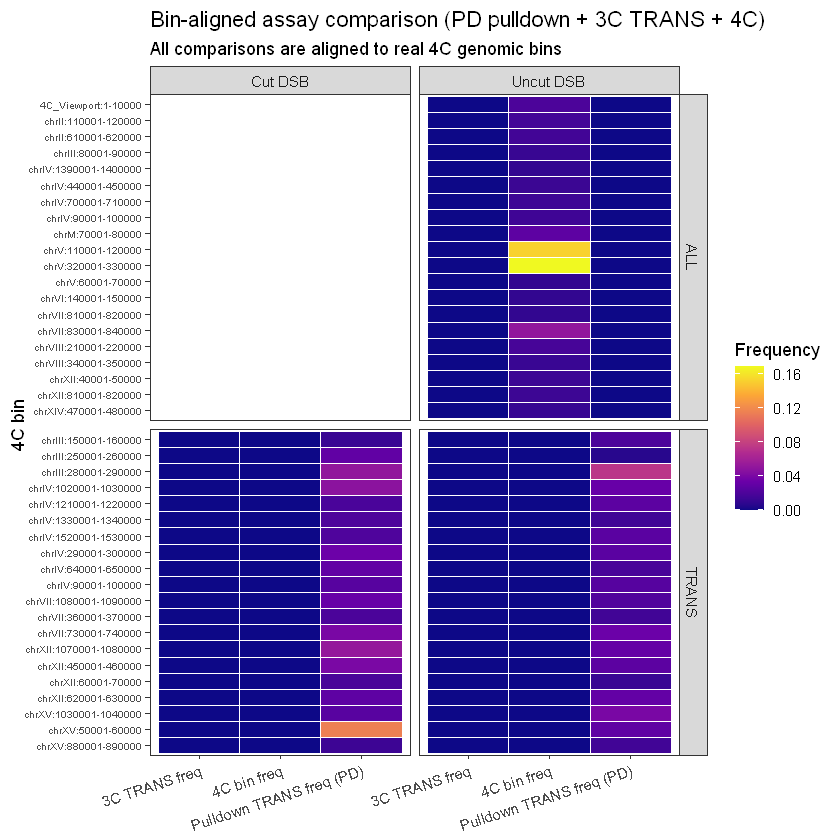

In [51]:
# ---- 4C-bin-aligned comparison layer (foundation tables + heatmap) ----
fourc_binned_file <- file.path(fourc_folder, 'binned_contact_counts.csv')

fourc_bins_ref <- if (file.exists(fourc_binned_file)) {
  readr::read_csv(
    fourc_binned_file,
    show_col_types = FALSE,
    col_types = readr::cols(.default = readr::col_character())
  ) %>%
    transmute(
      chrom = as.character(chrom),
      chrom_norm = toupper(as.character(chrom)),
      bin_start = readr::parse_double(as.character(bin_start)),
      bin_end = readr::parse_double(as.character(bin_end)),
      bin_id = as.character(bin_id)
    ) %>%
    filter(!is.na(chrom_norm), !is.na(bin_start), !is.na(bin_end), !is.na(bin_id)) %>%
    mutate(
      bin_mid = 0.5 * (bin_start + bin_end),
      bin_id_upper = toupper(bin_id)
    ) %>%
    distinct(chrom_norm, bin_id, bin_id_upper, bin_start, bin_end, bin_mid, .keep_all = TRUE)
} else {
  tibble(
    chrom = character(), chrom_norm = character(),
    bin_start = numeric(), bin_end = numeric(), bin_id = character(),
    bin_mid = numeric(), bin_id_upper = character()
  )
}

if (!exists('yeast_chr_lengths')) {
  yeast_chr_lengths <- c(
    CHRI = 230218, CHRII = 813184, CHRIII = 316620, CHRIV = 1531933,
    CHRV = 576874, CHRVI = 270161, CHRVII = 1090940, CHRVIII = 562643,
    CHRIX = 439888, CHRX = 745751, CHRXI = 666816, CHRXII = 1078177,
    CHRXIII = 924431, CHRXIV = 784333, CHRXV = 1091291, CHRXVI = 948066, CHRM = 85779
  )
}

bin_lookup <- fourc_bins_ref %>% select(bin_id_upper, bin_id) %>% distinct()

normalize_bin_id_case <- function(x) {
  x_up <- toupper(as.character(x))
  if (nrow(bin_lookup) == 0) return(x_up)
  out <- dplyr::left_join(tibble(bin_id_upper = x_up), bin_lookup, by = 'bin_id_upper') %>%
    mutate(bin_id = if_else(is.na(bin_id), bin_id_upper, bin_id)) %>%
    pull(bin_id)
  out
}

infer_fourc_bin <- function(location_chr, chrom_norm_chr) {
  loc <- as.character(location_chr)
  chrn <- as.character(chrom_norm_chr)
  out <- rep(NA_character_, length(loc))

  is_bin <- stringr::str_detect(loc, '(?i)^chr[0-9ivxm]+:[0-9]+-[0-9]+$')
  if (any(is_bin, na.rm = TRUE)) {
    out[is_bin] <- normalize_bin_id_case(loc[is_bin])
  }

  need_map <- is.na(out) & !is.na(chrn) & nzchar(chrn)
  if (any(need_map, na.rm = TRUE) && nrow(fourc_bins_ref) > 0) {
    idx <- suppressWarnings(as.numeric(stringr::str_extract(loc[need_map], '(?<=_L)\\d+')))
    idx_tbl <- tibble(chrom_norm = chrn[need_map], locus_idx = idx) %>%
      group_by(chrom_norm) %>%
      mutate(max_idx = suppressWarnings(max(locus_idx, na.rm = TRUE))) %>%
      ungroup()

    chr_len <- unname(yeast_chr_lengths[idx_tbl$chrom_norm])
    chr_len_obs <- fourc_bins_ref %>%
      group_by(chrom_norm) %>%
      summarise(chr_len_obs = max(bin_end, na.rm = TRUE), .groups = 'drop')

    idx_tbl <- idx_tbl %>%
      left_join(chr_len_obs, by = 'chrom_norm') %>%
      mutate(
        chr_len = coalesce(chr_len, chr_len_obs, max(fourc_bins_ref$bin_end, na.rm = TRUE)),
        max_idx = if_else(!is.finite(max_idx) | is.na(max_idx) | max_idx <= 0, 1, max_idx),
        pos_bp = if_else(is.finite(locus_idx) & !is.na(locus_idx), pmax(1, (locus_idx / max_idx) * chr_len), NA_real_)
      )

    mapped <- purrr::pmap_chr(
      list(idx_tbl$chrom_norm, idx_tbl$pos_bp),
      function(ch_use, pos_use) {
        if (is.na(ch_use) || is.na(pos_use) || !is.finite(pos_use)) return(NA_character_)
        cand <- fourc_bins_ref %>% filter(chrom_norm == ch_use)
        if (nrow(cand) == 0) return(NA_character_)
        cand$bin_id[[which.min(abs(cand$bin_mid - pos_use))]]
      }
    )

    out[need_map] <- mapped
  }

  out
}

# PD pulldown TRANS frequencies mapped to 4C bins
pd_trans_freq <- dat4 %>%
  mutate(
    state = assign_state(time_point, pd_state_map),
    location = as.character(allele),
    chromosome = extract_chr(location)
  ) %>%
  filter(combo %in% c('A_to_D', 'C_to_B')) %>%
  group_by(DSB, state, location, chromosome) %>%
  summarise(PD_TRANS_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state) %>%
  mutate(
    PD_TRANS_Total = sum(PD_TRANS_Counts, na.rm = TRUE),
    PD_TRANS_Freq = if_else(PD_TRANS_Total > 0, PD_TRANS_Counts / PD_TRANS_Total, 0)
  ) %>%
  ungroup() %>%
  mutate(location_bin = infer_fourc_bin(location, chromosome))

# 3C TRANS frequencies mapped to 4C bins
threec_trans_freq <- threec_local %>%
  select(DSB, repair_mode, state, location, ThreeC_TRANS_Freq) %>%
  distinct() %>%
  mutate(
    chromosome = extract_chr(location),
    location_bin = infer_fourc_bin(location, chromosome)
  )

# 4C bin frequencies
fourc_bin_freq <- fourc_sig %>%
  mutate(location_bin = normalize_bin_id_case(allele)) %>%
  group_by(DSB, state, location_bin) %>%
  summarise(Freq4C = mean(Freq4C, na.rm = TRUE), .groups = 'drop')

# Bin-aligned assay table
bin_aligned_assay_table <- full_join(
  pd_trans_freq %>% select(DSB, state, location_bin, PD_TRANS_Freq),
  threec_trans_freq %>% select(DSB, state, location_bin, ThreeC_TRANS_Freq),
  by = c('DSB', 'state', 'location_bin')
 ) %>%
  full_join(
    fourc_bin_freq %>% select(DSB, state, location_bin, Freq4C),
    by = c('DSB', 'state', 'location_bin')
  ) %>%
  mutate(
    PD_TRANS_Freq = replace_na(PD_TRANS_Freq, 0),
    ThreeC_TRANS_Freq = replace_na(ThreeC_TRANS_Freq, 0),
    Freq4C = replace_na(Freq4C, 0),
    joint_signal = PD_TRANS_Freq + ThreeC_TRANS_Freq + Freq4C
  )

bin_aligned_top <- bin_aligned_assay_table %>%
  filter(!is.na(location_bin), joint_signal > 0) %>%
  group_by(DSB, state) %>%
  slice_max(order_by = joint_signal, n = 20, with_ties = FALSE) %>%
  ungroup()

if (nrow(bin_aligned_top) > 0) {
  p_bin_aligned_assay_heatmap <- ggplot(
    bin_aligned_top %>%
      pivot_longer(
        cols = c(PD_TRANS_Freq, ThreeC_TRANS_Freq, Freq4C),
        names_to = 'assay',
        values_to = 'freq_signal'
      ) %>%
      mutate(
        assay = recode(
          assay,
          PD_TRANS_Freq = 'Pulldown TRANS freq (PD)',
          ThreeC_TRANS_Freq = '3C TRANS freq',
          Freq4C = '4C bin freq'
        )
      ),
    aes(x = assay, y = forcats::fct_rev(location_bin), fill = freq_signal)
  ) +
    geom_tile(color = 'white', linewidth = 0.25) +
    facet_grid(DSB ~ state, scales = 'free_y', space = 'free_y') +
    scale_fill_viridis_c(option = 'C') +
    theme_bw(base_size = 11) +
    theme(
      axis.text.y = element_text(size = 6),
      axis.text.x = element_text(angle = 18, hjust = 1),
      panel.grid = element_blank()
    ) +
    labs(
      title = 'Bin-aligned assay comparison (PD pulldown + 3C TRANS + 4C)',
      subtitle = 'All comparisons are aligned to real 4C genomic bins',
      x = NULL,
      y = '4C bin',
      fill = 'Frequency'
    )
  print(p_bin_aligned_assay_heatmap)
} else {
  p_bin_aligned_assay_heatmap <- NULL
  message('No non-zero bin-aligned assay rows available for heatmap.')
}

list(
  bin_aligned_assay_preview = bin_aligned_assay_table %>% arrange(desc(joint_signal)) %>% head(20),
  pd_trans_preview = pd_trans_freq %>% head(20),
  threec_trans_preview = threec_trans_freq %>% head(20)
 )

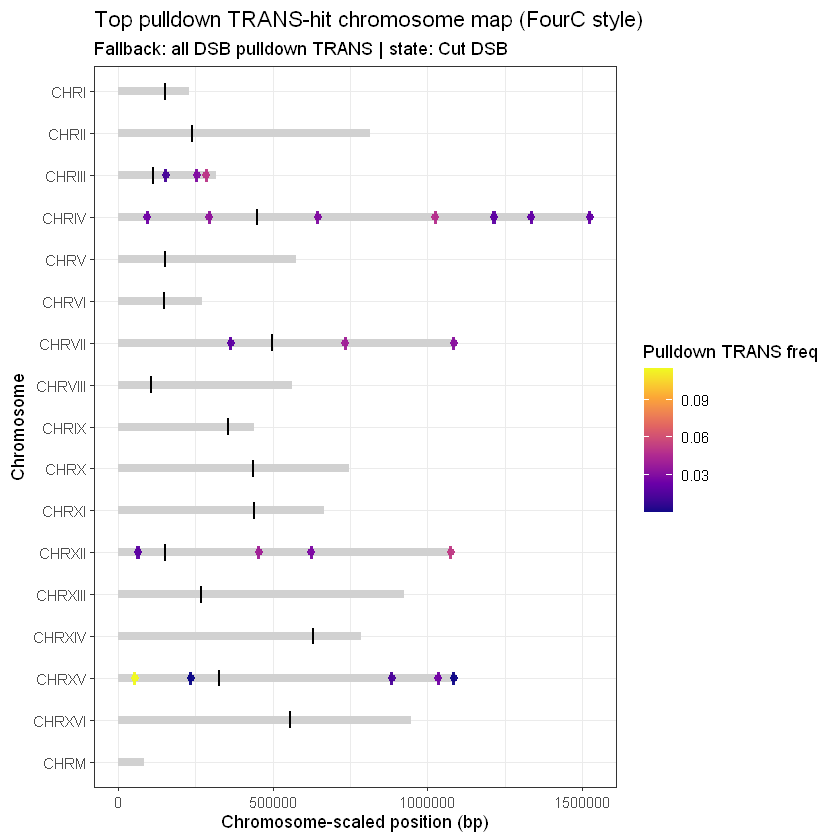

chrom_norm,bin_id,chr_len,x_start,x_end,pos_bp,PD_TRANS_Freq
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CHRXV,chrXV:50001-60000,1091291,50001,60000,55000.5,0.11490574
CHRXII,chrXII:1070001-1080000,1078177,1070001,1078177,1075000.5,0.05192913
CHRIII,chrIII:280001-290000,316620,280001,290000,285000.5,0.05048241
CHRIV,chrIV:1020001-1030000,1531933,1020001,1030000,1025000.5,0.04776646
CHRXII,chrXII:450001-460000,1078177,450001,460000,455000.5,0.03989722
CHRVII,chrVII:730001-740000,1090940,730001,740000,735000.5,0.03975276
CHRIV,chrIV:290001-300000,1531933,290001,300000,295000.5,0.03433530
CHRVII,chrVII:1080001-1090000,1090940,1080001,1090000,1085000.5,0.03236645
CHRIV,chrIV:640001-650000,1531933,640001,650000,645000.5,0.02952048


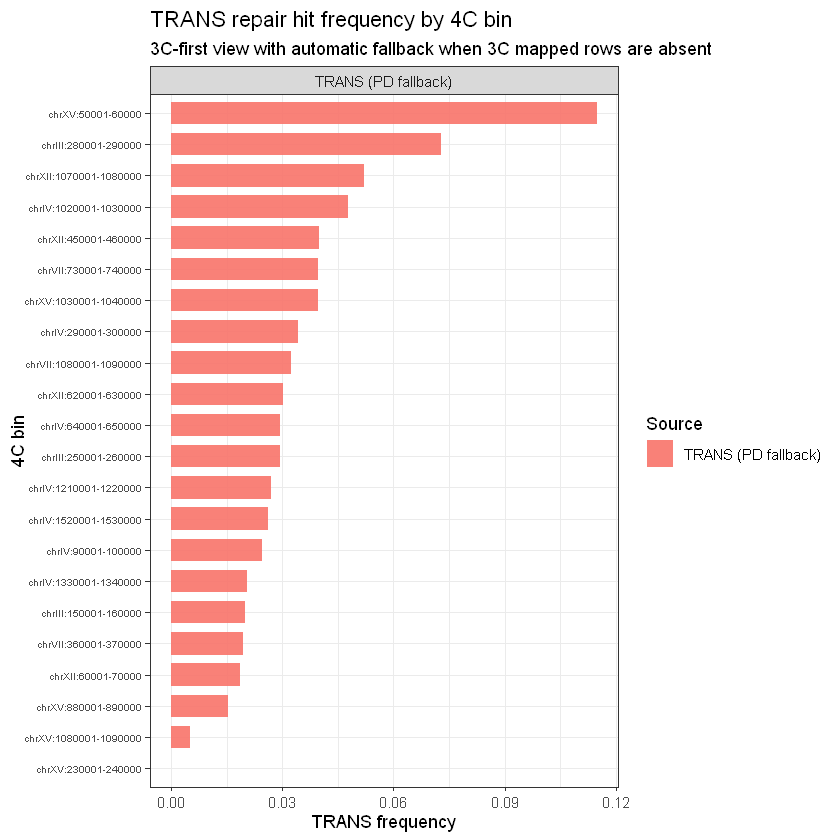

In [53]:
# ---- FourC-style chromosome map for PD pulldown TRANS + 3C TRANS frequency ----
pd_trans_dsb1_map_table <- tibble()
threec_trans_frequency_table <- tibble()
p_pulldown_trans_dsb1_map <- NULL
p_threec_trans_frequency <- NULL

chrom_order <- c('CHRI','CHRII','CHRIII','CHRIV','CHRV','CHRVI','CHRVII','CHRVIII','CHRIX','CHRX','CHRXI','CHRXII','CHRXIII','CHRXIV','CHRXV','CHRXVI','CHRM')

yeast_centromeres <- c(
  CHRI = 151583, CHRII = 238323, CHRIII = 114385, CHRIV = 449711,
  CHRV = 151465, CHRVI = 148510, CHRVII = 497038, CHRVIII = 105703,
  CHRIX = 355629, CHRX = 436425, CHRXI = 440246, CHRXII = 150947,
  CHRXIII = 268031, CHRXIV = 628758, CHRXV = 326584, CHRXVI = 556070
 )

chrom_baseline_all <- tibble(
  chrom_norm = chrom_order,
  chr_len = as.numeric(unname(yeast_chr_lengths[chrom_order]))
 ) %>% filter(is.finite(chr_len), chr_len > 0)

# Build pulldown map rows with fallback priority: DSB1 -> any DSB -> top 4C bins
if (exists('pd_trans_freq') && nrow(pd_trans_freq) > 0) {
  pd_all <- pd_trans_freq %>%
    filter(is.finite(PD_TRANS_Freq), !is.na(location_bin)) %>%
    mutate(
      chromosome = if_else(!is.na(chromosome), toupper(chromosome), toupper(stringr::str_extract(location_bin, '(?i)^chr[0-9ivxm]+'))),
      location_bin_upper = toupper(location_bin)
    )

  pd_dsb1 <- pd_all %>% filter(DSB == 'DSB1')
  pd_any <- pd_all

  pd_pick <- if (nrow(pd_dsb1) > 0) pd_dsb1 else pd_any
  source_label <- if (nrow(pd_dsb1) > 0) 'DSB1 pulldown TRANS' else 'Fallback: all DSB pulldown TRANS'

  if (nrow(pd_pick) > 0) {
    preferred_state <- if (any(pd_pick$state == state_cut)) state_cut else pd_pick$state[[1]]

    pd_trans_dsb1_map_table <- pd_pick %>%
      filter(state == preferred_state) %>%
      left_join(
        fourc_bins_ref %>% select(chrom_norm, bin_id, bin_id_upper, bin_start, bin_end),
        by = c('location_bin_upper' = 'bin_id_upper'),
        relationship = 'many-to-many'
      ) %>%
      mutate(
        chrom_norm = coalesce(chrom_norm, chromosome),
        chrom_norm = toupper(chrom_norm),
        bin_id = coalesce(bin_id, location_bin),
        bin_start = coalesce(bin_start, readr::parse_double(stringr::str_extract(location_bin, '(?<=:)[0-9]+'))),
        bin_end = coalesce(bin_end, readr::parse_double(stringr::str_extract(location_bin, '(?<=-)[0-9]+'))),
        chr_len = unname(yeast_chr_lengths[chrom_norm]),
        chr_len = coalesce(chr_len, bin_end, 1e6),
        pos_bp = 0.5 * (bin_start + bin_end),
        x_start = pmax(1, bin_start),
        x_end = pmin(chr_len, bin_end)
      ) %>%
      filter(!is.na(chrom_norm), !is.na(x_start), !is.na(x_end), is.finite(PD_TRANS_Freq)) %>%
      group_by(chrom_norm, bin_id, chr_len, x_start, x_end, pos_bp) %>%
      summarise(PD_TRANS_Freq = max(PD_TRANS_Freq), .groups = 'drop') %>%
      arrange(desc(PD_TRANS_Freq)) %>%
      slice_head(n = 50)

    if (nrow(pd_trans_dsb1_map_table) > 0) {
      p_pulldown_trans_dsb1_map <- ggplot() +
        geom_segment(
          data = chrom_baseline_all,
          aes(x = 1, xend = chr_len, y = factor(chrom_norm, levels = rev(chrom_order)), yend = factor(chrom_norm, levels = rev(chrom_order))),
          color = 'grey82', linewidth = 2.4
        ) +
        geom_segment(
          data = pd_trans_dsb1_map_table,
          aes(
            x = x_start, xend = x_end,
            y = factor(chrom_norm, levels = rev(chrom_order)),
            yend = factor(chrom_norm, levels = rev(chrom_order)),
            color = PD_TRANS_Freq
          ),
          linewidth = 3.8, alpha = 0.96
        ) +
        geom_point(
          data = pd_trans_dsb1_map_table,
          aes(x = pos_bp, y = factor(chrom_norm, levels = rev(chrom_order)), color = PD_TRANS_Freq),
          size = 2.0, alpha = 0.96
        ) +
        geom_segment(
          data = chrom_baseline_all %>% mutate(cen = as.numeric(unname(yeast_centromeres[chrom_norm]))) %>% filter(!is.na(cen)),
          aes(
            x = cen, xend = cen,
            y = as.numeric(factor(chrom_norm, levels = rev(chrom_order))) - 0.20,
            yend = as.numeric(factor(chrom_norm, levels = rev(chrom_order))) + 0.20
          ),
          inherit.aes = FALSE, color = 'black', linewidth = 0.7
        ) +
        scale_color_viridis_c(option = 'C') +
        theme_bw(base_size = 11) +
        labs(
          title = 'Top pulldown TRANS-hit chromosome map (FourC style)',
          subtitle = paste0(source_label, ' | state: ', preferred_state),
          x = 'Chromosome-scaled position (bp)',
          y = 'Chromosome',
          color = 'Pulldown TRANS freq'
        )
      print(p_pulldown_trans_dsb1_map)
    }
  }
}

# Hard fallback: if no pulldown rows, show top 4C bins in same map style for context
if (is.null(p_pulldown_trans_dsb1_map) && exists('fourc_bin_freq') && nrow(fourc_bin_freq) > 0) {
  fourc_map_fallback <- fourc_bin_freq %>%
    filter(!is.na(location_bin), is.finite(Freq4C), Freq4C > 0) %>%
    mutate(
      chrom_norm = toupper(stringr::str_extract(location_bin, '(?i)^chr[0-9ivxm]+')),
      x_start = readr::parse_double(stringr::str_extract(location_bin, '(?<=:)[0-9]+')),
      x_end = readr::parse_double(stringr::str_extract(location_bin, '(?<=-)[0-9]+')),
      pos_bp = 0.5 * (x_start + x_end),
      chr_len = unname(yeast_chr_lengths[chrom_norm]),
      chr_len = coalesce(chr_len, x_end, 1e6)
    ) %>%
    filter(!is.na(chrom_norm), !is.na(x_start), !is.na(x_end)) %>%
    arrange(desc(Freq4C)) %>%
    slice_head(n = 50)

  if (nrow(fourc_map_fallback) > 0) {
    p_pulldown_trans_dsb1_map <- ggplot() +
      geom_segment(
        data = chrom_baseline_all,
        aes(x = 1, xend = chr_len, y = factor(chrom_norm, levels = rev(chrom_order)), yend = factor(chrom_norm, levels = rev(chrom_order))),
        color = 'grey82', linewidth = 2.4
      ) +
      geom_segment(
        data = fourc_map_fallback,
        aes(
          x = x_start, xend = x_end,
          y = factor(chrom_norm, levels = rev(chrom_order)),
          yend = factor(chrom_norm, levels = rev(chrom_order)),
          color = Freq4C
        ),
        linewidth = 3.8, alpha = 0.96
      ) +
      geom_point(
        data = fourc_map_fallback,
        aes(x = pos_bp, y = factor(chrom_norm, levels = rev(chrom_order)), color = Freq4C),
        size = 2.0, alpha = 0.96
      ) +
      scale_color_viridis_c(option = 'C') +
      theme_bw(base_size = 11) +
      labs(
        title = 'Top chromosome bins (FourC-style fallback map)',
        subtitle = 'No mappable DSB1 pulldown TRANS rows; showing top available 4C bins for positional context',
        x = 'Chromosome-scaled position (bp)',
        y = 'Chromosome',
        color = '4C frequency'
      )
    print(p_pulldown_trans_dsb1_map)
  }
}

# 3C TRANS frequency view with fallback state (and fallback dataset)
if (exists('threec_trans_freq') && nrow(threec_trans_freq) > 0) {
  threec_source <- threec_trans_freq %>%
    filter(!is.na(location_bin), is.finite(ThreeC_TRANS_Freq))

  if (nrow(threec_source) > 0) {
    state_priority <- threec_source %>%
      group_by(state) %>%
      summarise(total_freq = sum(ThreeC_TRANS_Freq, na.rm = TRUE), .groups = 'drop') %>%
      arrange(desc(total_freq))

    preferred_threec_state <- if (state_cut %in% state_priority$state) state_cut else state_priority$state[[1]]

    threec_trans_frequency_table <- threec_source %>%
      filter(state == preferred_threec_state) %>%
      group_by(DSB, location_bin) %>%
      summarise(ThreeC_TRANS_Freq = max(ThreeC_TRANS_Freq, na.rm = TRUE), .groups = 'drop') %>%
      group_by(DSB) %>%
      slice_max(order_by = ThreeC_TRANS_Freq, n = 25, with_ties = FALSE) %>%
      ungroup()
  }
}

if (nrow(threec_trans_frequency_table) == 0 && exists('pd_trans_freq') && nrow(pd_trans_freq) > 0) {
  threec_trans_frequency_table <- pd_trans_freq %>%
    filter(!is.na(location_bin), is.finite(PD_TRANS_Freq)) %>%
    group_by(DSB, location_bin) %>%
    summarise(ThreeC_TRANS_Freq = max(PD_TRANS_Freq, na.rm = TRUE), .groups = 'drop') %>%
    group_by(DSB) %>%
    slice_max(order_by = ThreeC_TRANS_Freq, n = 25, with_ties = FALSE) %>%
    ungroup() %>%
    mutate(DSB = paste0(DSB, ' (PD fallback)'))
}

if (nrow(threec_trans_frequency_table) > 0) {
  p_threec_trans_frequency <- ggplot(
    threec_trans_frequency_table,
    aes(x = ThreeC_TRANS_Freq, y = forcats::fct_reorder(location_bin, ThreeC_TRANS_Freq), fill = DSB)
  ) +
    geom_col(width = 0.72, alpha = 0.92) +
    facet_wrap(~ DSB, scales = 'free_y') +
    theme_bw(base_size = 11) +
    theme(axis.text.y = element_text(size = 6)) +
    labs(
      title = 'TRANS repair hit frequency by 4C bin',
      subtitle = '3C-first view with automatic fallback when 3C mapped rows are absent',
      x = 'TRANS frequency',
      y = '4C bin',
      fill = 'Source'
    )
  print(p_threec_trans_frequency)
} else {
  message('No mappable TRANS frequency rows were available for 3C or fallback source.')
}

list(
  pulldown_dsb1_map_preview = pd_trans_dsb1_map_table %>% head(20),
  threec_trans_frequency_preview = threec_trans_frequency_table %>% head(20)
 )

In [54]:
# ---- Save outputs ----
out_dir <- file.path(getwd(), 'Outputs', 'PD_3C_4C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Remove legacy files from previous plot variants
legacy_pngs <- c(
  'multiassay_localization_hotspots.png',
  'multiassay_localization_rank.png'
)
legacy_paths <- file.path(out_dir, legacy_pngs)
legacy_paths <- legacy_paths[file.exists(legacy_paths)]
if (length(legacy_paths) > 0) invisible(file.remove(legacy_paths))

# Informative figure artifacts
if (exists('p_hotspot_signature_heatmap') && !is.null(p_hotspot_signature_heatmap)) ggsave(file.path(out_dir, 'multiassay_hotspot_signature_heatmap.png'), p_hotspot_signature_heatmap, width = 14, height = 10, dpi = 220)
if (exists('p_score_components') && !is.null(p_score_components)) ggsave(file.path(out_dir, 'multiassay_score_components.png'), p_score_components, width = 14, height = 10, dpi = 220)
if (exists('p_assay_agreement') && !is.null(p_assay_agreement)) ggsave(file.path(out_dir, 'multiassay_assay_agreement_scatter.png'), p_assay_agreement, width = 13, height = 10, dpi = 220)
if (exists('p_chromosome_track_map') && !is.null(p_chromosome_track_map)) ggsave(file.path(out_dir, 'chromosome_enrichment_track_map.png'), p_chromosome_track_map, width = 15, height = 10, dpi = 220)

# New requested figure artifacts (4C-bin aligned)
if (exists('p_bin_aligned_assay_heatmap') && !is.null(p_bin_aligned_assay_heatmap)) ggsave(file.path(out_dir, 'bin_aligned_assay_comparison_heatmap.png'), p_bin_aligned_assay_heatmap, width = 14, height = 10, dpi = 220)
if (exists('p_pulldown_trans_dsb1_map') && !is.null(p_pulldown_trans_dsb1_map)) ggsave(file.path(out_dir, 'pulldown_trans_dsb1_chromosome_map.png'), p_pulldown_trans_dsb1_map, width = 14, height = 9, dpi = 220)
if (exists('p_threec_trans_frequency') && !is.null(p_threec_trans_frequency)) ggsave(file.path(out_dir, 'threec_trans_frequency_hits.png'), p_threec_trans_frequency, width = 13, height = 9, dpi = 220)

# Table/CSV artifacts
if (exists('localization_ranked')) readr::write_csv(localization_ranked, file.path(out_dir, 'localization_ranked_multiassay.csv'))
if (exists('top_hotspots')) readr::write_csv(top_hotspots, file.path(out_dir, 'localization_top_hotspots.csv'))
if (exists('hotspot_signature_table')) readr::write_csv(hotspot_signature_table, file.path(out_dir, 'hotspot_signature_table.csv'))
if (exists('localization_rank_table')) readr::write_csv(localization_rank_table, file.path(out_dir, 'localization_rank_table.csv'))
if (exists('chromosome_mobility')) readr::write_csv(chromosome_mobility, file.path(out_dir, 'chromosome_mobility_index.csv'))
if (exists('chrom_corr')) readr::write_csv(chrom_corr, file.path(out_dir, 'chromosome_correlation_enrichment.csv'))
if (exists('chrom_track_df')) readr::write_csv(chrom_track_df, file.path(out_dir, 'chromosome_enrichment_track_map_table.csv'))

# New requested tables
if (exists('bin_aligned_assay_table')) readr::write_csv(bin_aligned_assay_table, file.path(out_dir, 'bin_aligned_assay_table.csv'))
if (exists('pd_trans_dsb1_map_table')) readr::write_csv(pd_trans_dsb1_map_table, file.path(out_dir, 'pulldown_trans_dsb1_map_table.csv'))
if (exists('threec_trans_frequency_table')) readr::write_csv(threec_trans_frequency_table, file.path(out_dir, 'threec_trans_frequency_table.csv'))

message('Saved outputs to: ', out_dir)

Saved outputs to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/PD_3C_4C



## Final cross-assay interpretation guardrails (design-consistent)

Use the following constraints for all PD/3C/4C conclusions in this notebook:

- The experiment is a pooled-strain design (20+ strains).
- **DSB1 varies by strain** across a fixed locus panel.
- **DSB2 is batch-specific**: Batch 4 = Chr VII, Batch 6 = Chr IV, Batch 8 = Chr XV.
- T0 is pre-induction fixation baseline; induced endpoint state is post-induction (e.g., T120/T180 by assay).

### Required interpretation rules

1. Interpret trans behavior **within batch (anchor context)**, not as one pooled cross-batch DSB2 signal.
2. Compare assays by matching biological state first (Uncut vs Cut), then by batch/anchor context.
3. Treat pooled-across-batch summaries as descriptive unless explicitly modeled for batch-specific anchors.

### Reporting statement

All integrated PD/3C/4C conclusions in this report are **batch-specific DSB2-anchor interpretations** under the pooled-strain design.